In [1]:

!pip install -q pyclipper shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 16.2 MB/s eta 0:00:00


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Polygon
import pyclipper
import json
import random
import os


In [3]:

# ============== DETERMINISTIC SEED ==============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✓ Random seed set to {SEED} (fully deterministic)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

IMG_SIZE = 640


✓ Random seed set to 42 (fully deterministic)
Device: cuda


In [4]:

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/train-ocr-model')
MULTI_IMAGE_DIR = DATA_DIR / 'multiple_image_data'

json_path = MULTI_IMAGE_DIR / 'multiple_image.json'

with open(json_path, 'r') as f:
    all_annotations = json.load(f)

print(f"{'='*60}")
print(f"LOADING DATASET")
print(f"{'='*60}")
print(f"  JSON file: {json_path.name}")
print(f"  Total annotation entries: {len(all_annotations)}")

# Parse all images and their annotations
dataset_entries = []  # List of {image_path, polygons, texts}

for entry in all_annotations:
    # Get image filename from file_upload field
    image_filename = entry.get('file_upload', '')
    image_path = MULTI_IMAGE_DIR / image_filename

    if not image_path.exists():
        print(f"  ⚠ Image not found: {image_filename}, skipping...")
        continue

    # Get annotations
    annotations = entry.get('annotations', [])
    if not annotations:
        print(f"  ⚠ No annotations for: {image_filename}, skipping...")
        continue

    results = annotations[0].get('result', [])

    # Get image dimensions from first result
    orig_w = results[0]['original_width'] if results else 100
    orig_h = results[0]['original_height'] if results else 100

    # Pair polygon + transcription by ID
    poly_results = {}   # id -> points
    text_results = {}   # id -> text

    for r in results:
        rid = r['id']
        if r['type'] == 'polygon':
            points_pct = r['value']['points']
            # Convert percentage (0-100) to pixel coordinates
            pixel_points = []
            for px, py in points_pct:
                pixel_points.append([px * orig_w / 100.0, py * orig_h / 100.0])
            poly_results[rid] = np.array(pixel_points, dtype=np.float32)
        elif r['type'] == 'textarea':
            text_results[rid] = r['value']['text'][0] if r['value']['text'] else ''

    # Build polygon list for this image
    polygons = []
    texts = []
    for rid, poly in poly_results.items():
        text = text_results.get(rid, '')
        polygons.append(poly)
        texts.append(text)

    dataset_entries.append({
        'image_path': image_path,
        'image_filename': image_filename,
        'polygons': polygons,
        'texts': texts,
        'orig_w': orig_w,
        'orig_h': orig_h,
    })

print(f"\n  ✓ Successfully loaded {len(dataset_entries)} images:")
for i, entry in enumerate(dataset_entries):
    print(f"    [{i}] {entry['image_filename'][:50]}... "
          f"→ {len(entry['polygons'])} text regions, "
          f"size: {entry['orig_w']}×{entry['orig_h']}")

total_regions = sum(len(e['polygons']) for e in dataset_entries)
print(f"\n  Total text regions across all images: {total_regions}")

LOADING DATASET
  JSON file: multiple_image.json
  Total annotation entries: 5

  ✓ Successfully loaded 5 images:
    [0] 2a9f6148-Screenshot_2026-02-12_at_4.38.45PM.png... → 80 text regions, size: 770×972
    [1] bd7826d8-Screenshot_2026-02-12_at_5.42.21PM.png... → 80 text regions, size: 768×976
    [2] 98b6cb49-Screenshot_2026-02-12_at_6.51.39PM.png... → 80 text regions, size: 748×944
    [3] 8f0859a0-Screenshot_2026-02-12_at_8.16.24PM.png... → 80 text regions, size: 760×970
    [4] 0125a3c3-Screenshot_2026-02-12_at_8.46.51PM.png... → 80 text regions, size: 754×970

  Total text regions across all images: 400


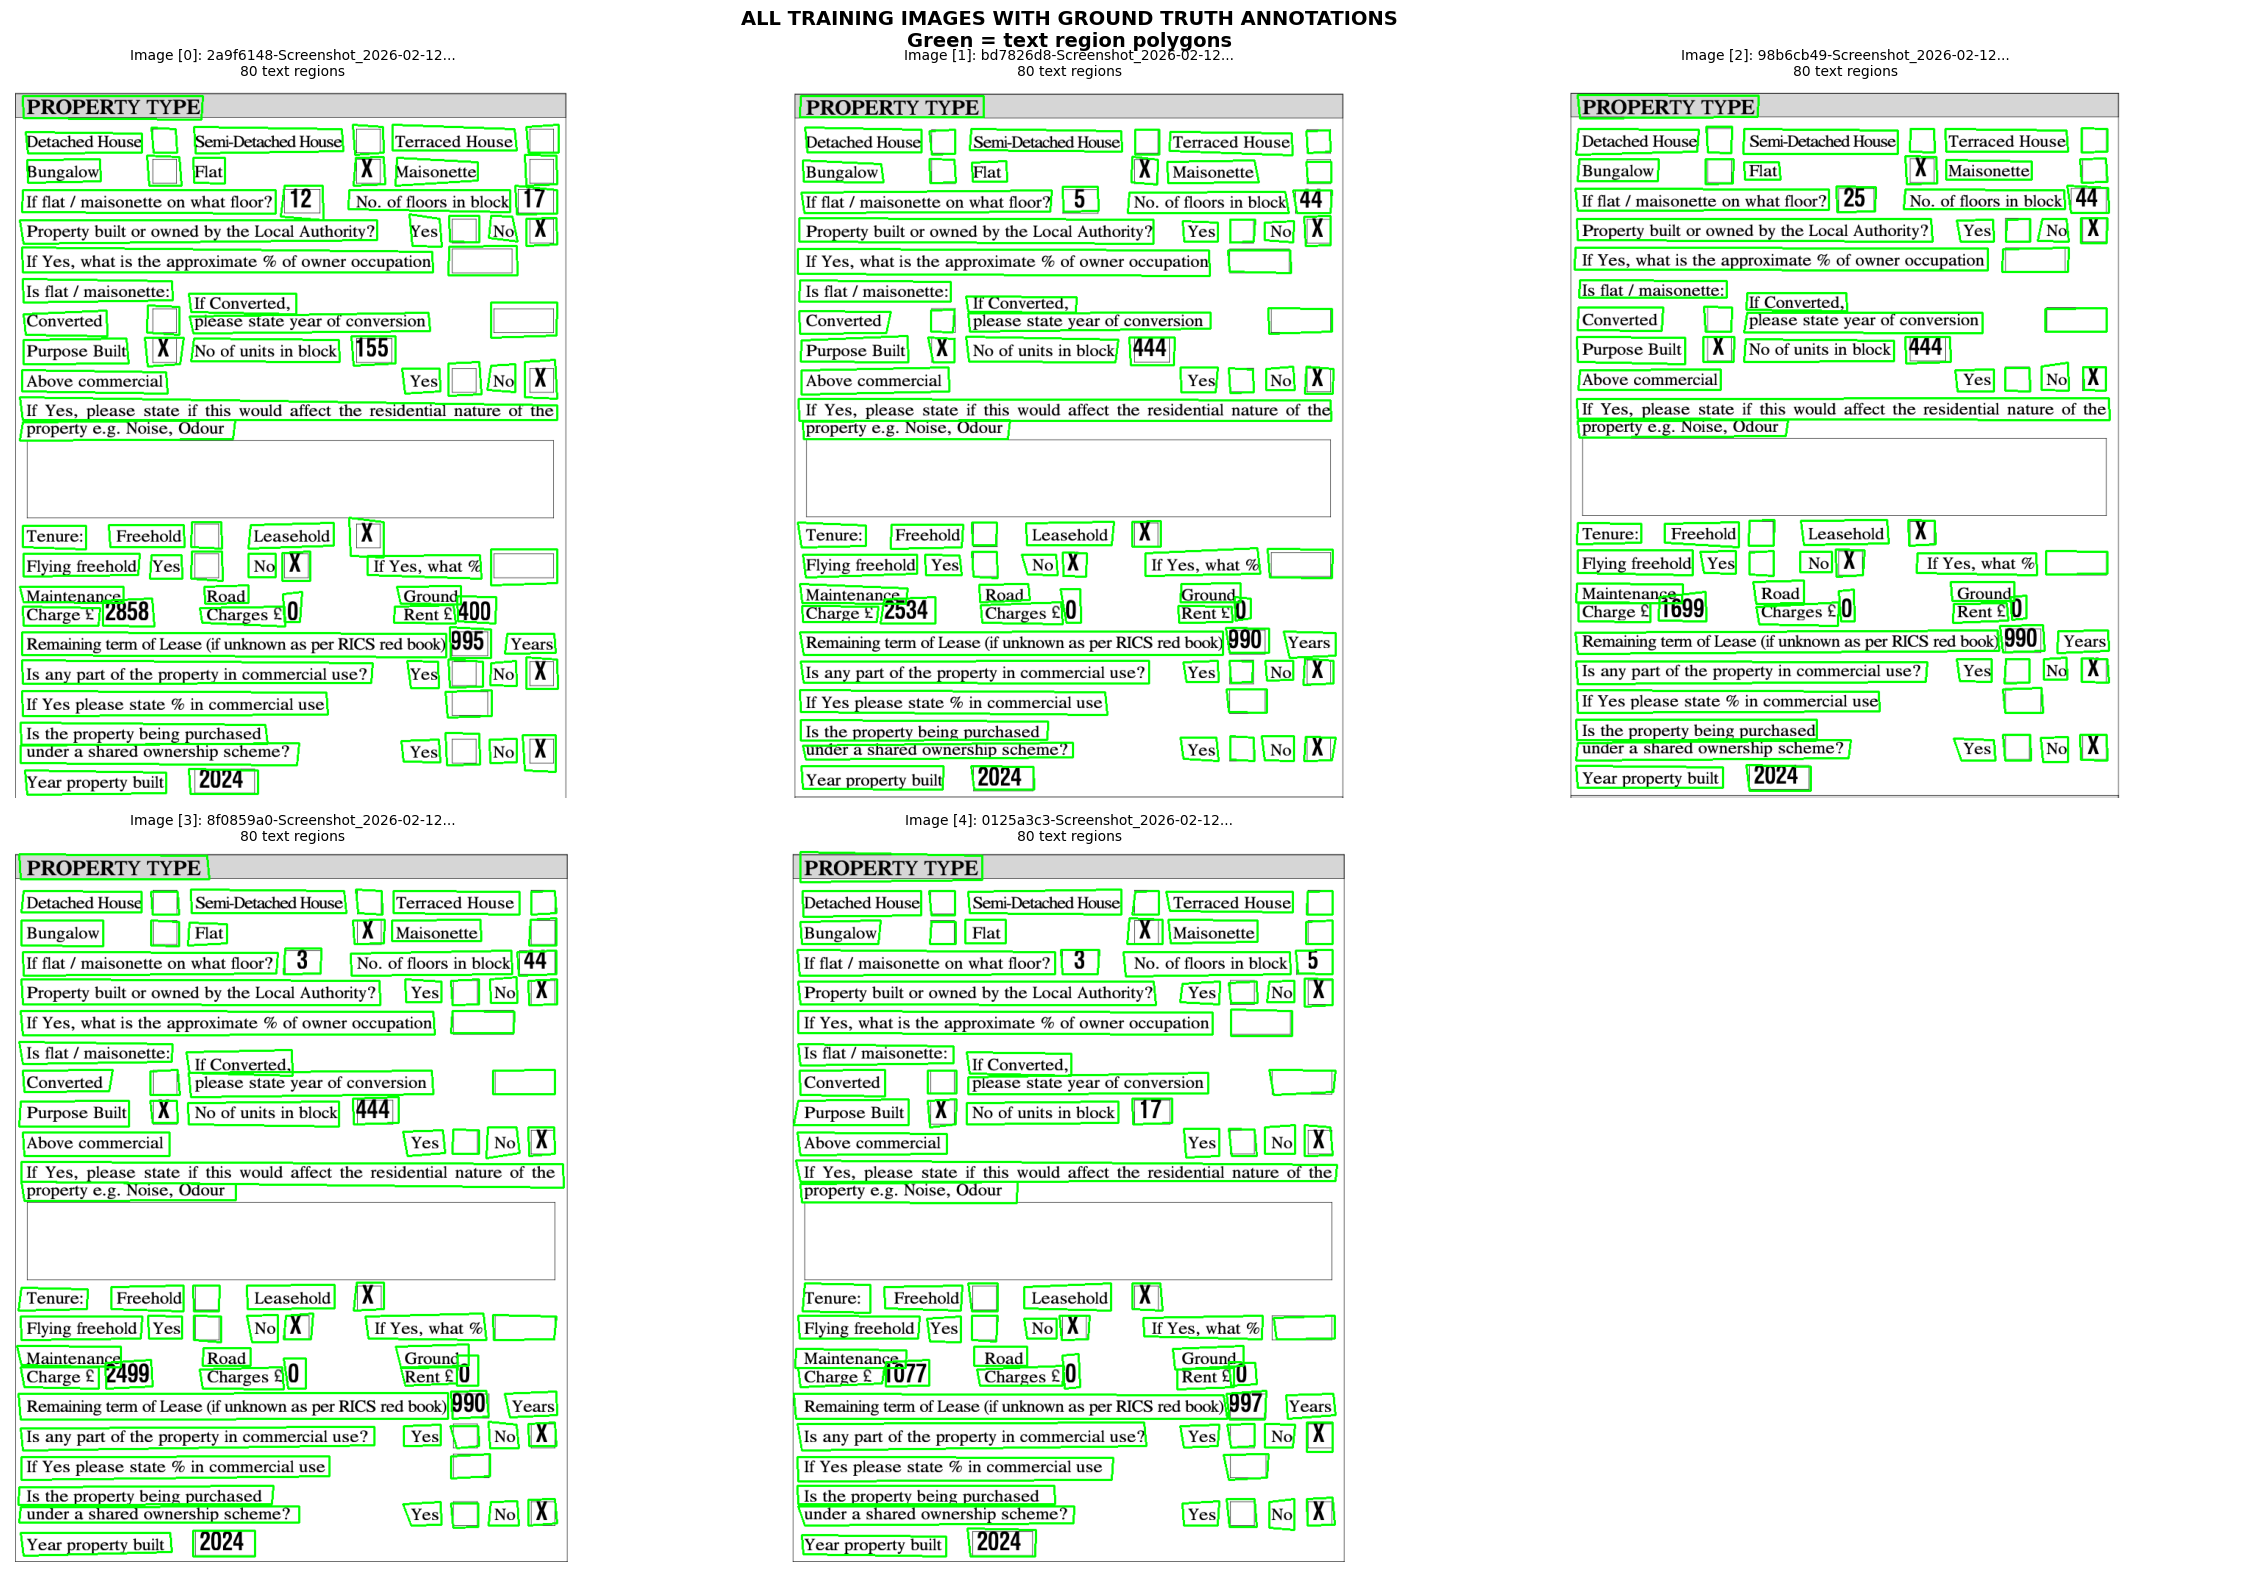

In [5]:

n_images = len(dataset_entries)
cols = min(3, n_images)
rows = (n_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 8 * rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = axes[np.newaxis, :]
elif cols == 1:
    axes = axes[:, np.newaxis]

for idx, entry in enumerate(dataset_entries):
    r, c = divmod(idx, cols)
    ax = axes[r, c]

    img = cv2.imread(str(entry['image_path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    vis = img.copy()
    for poly in entry['polygons']:
        pts = poly.astype(np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2)

    ax.imshow(vis)
    ax.set_title(f"Image [{idx}]: {entry['image_filename'][:30]}...\n"
                 f"{len(entry['polygons'])} text regions", fontsize=10)
    ax.axis('off')

# Hide empty subplots
for idx in range(n_images, rows * cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis('off')

plt.suptitle('ALL TRAINING IMAGES WITH GROUND TRUTH ANNOTATIONS\n'
             'Green = text region polygons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

✓ Dataset created: 5 images
  Image tensor shape:     torch.Size([3, 640, 640])  →  (C=3, H=640, W=640)
  Prob map tensor shape:  torch.Size([1, 640, 640])  →  (C=1, H=640, W=640)
  Thresh map tensor shape:torch.Size([1, 640, 640])
  Thresh mask shape:      torch.Size([1, 640, 640])


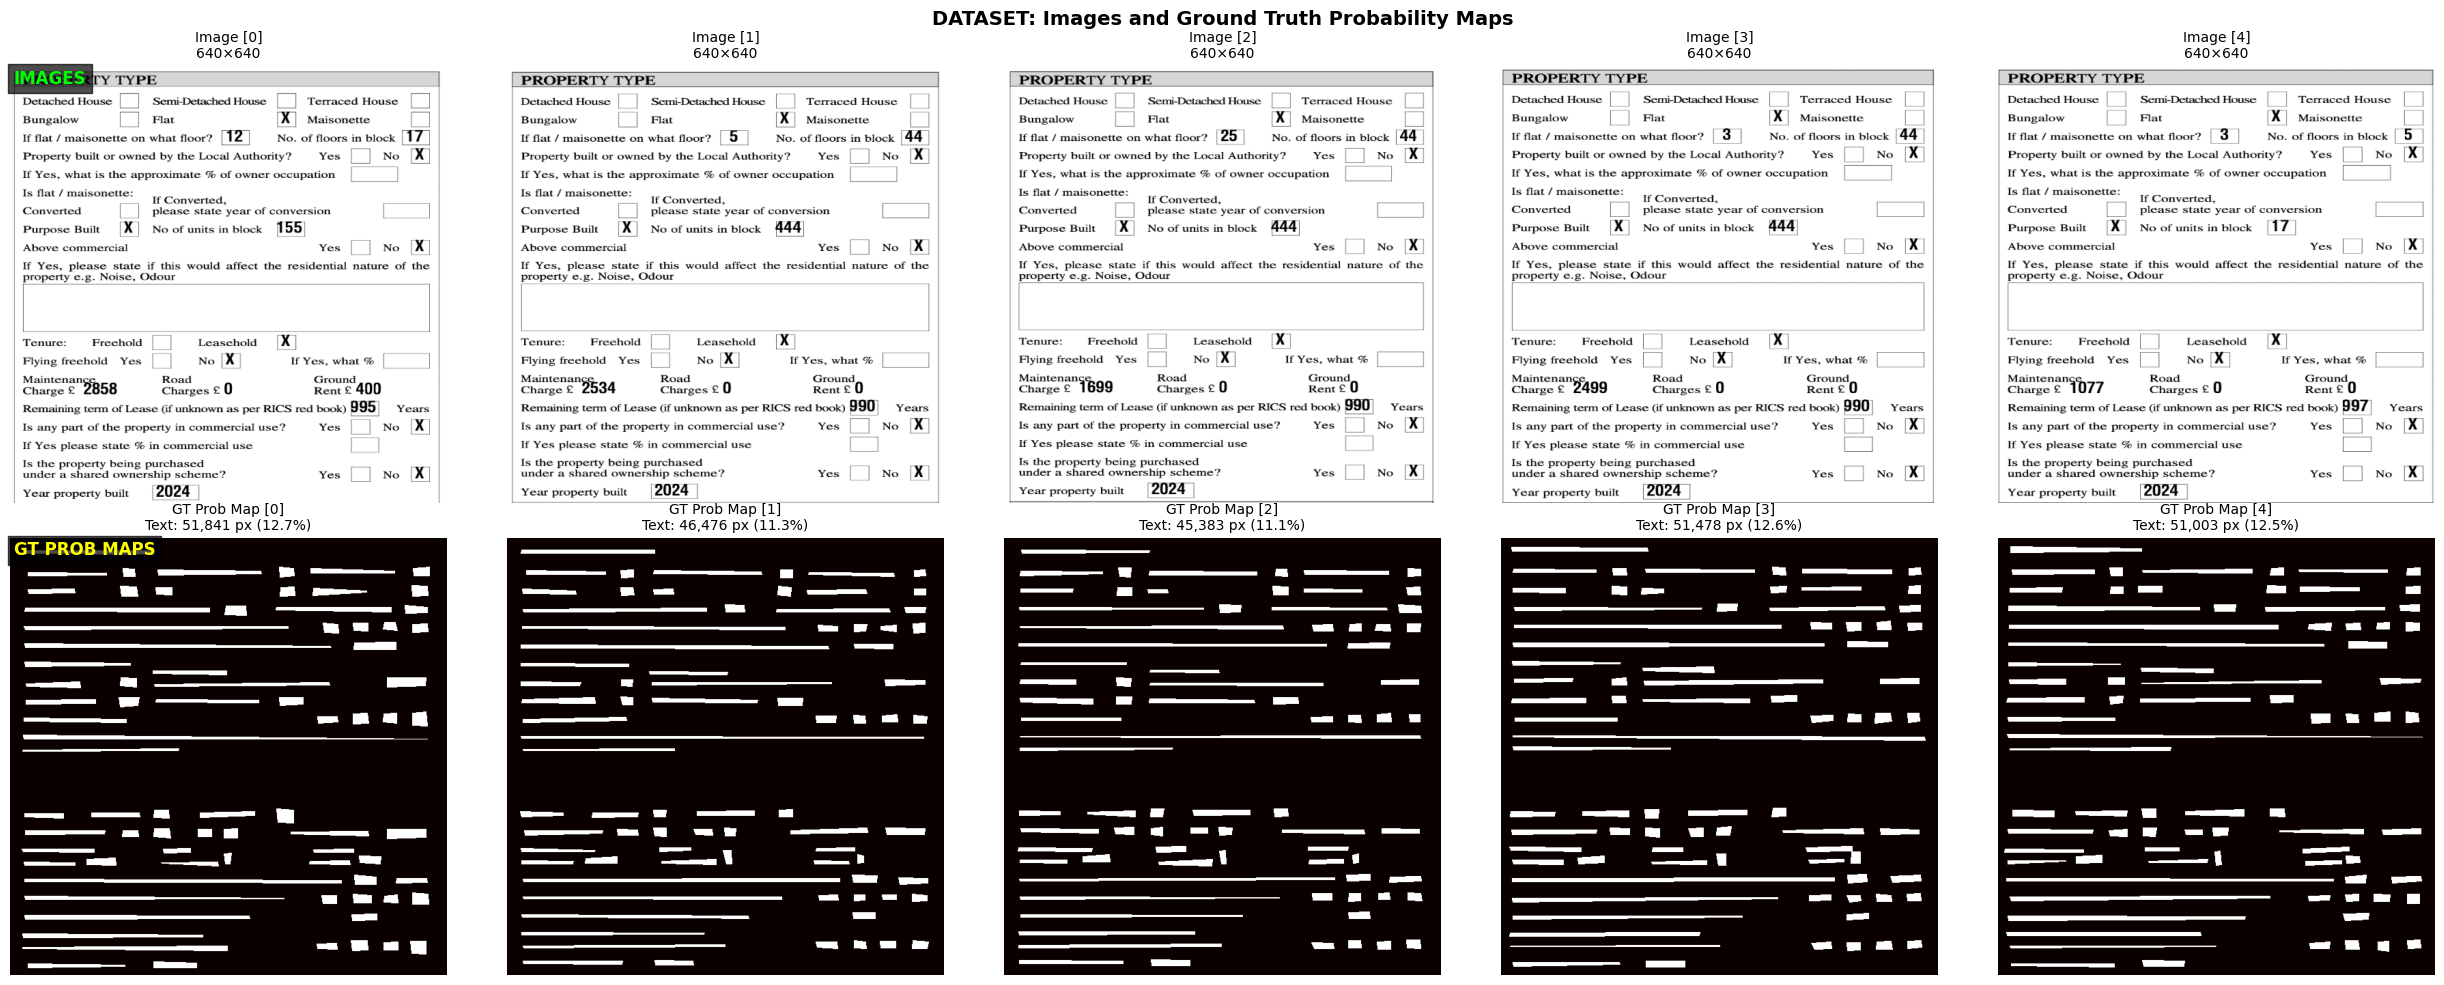

In [6]:

def shrink_polygon(polygon, shrink_ratio=0.4):
    """Shrink polygon inward by shrink_ratio for probability map GT."""
    poly = Polygon(polygon)
    if not poly.is_valid or poly.area < 1:
        return None

    area = poly.area
    perimeter = poly.length
    if perimeter == 0:
        return None

    shrink_distance = area * (1 - shrink_ratio ** 2) / perimeter

    pco = pyclipper.PyclipperOffset()
    pco.AddPath(polygon.astype(np.int64).tolist(),
                pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)

    shrunk = pco.Execute(-shrink_distance)

    if len(shrunk) == 0:
        return None
    return np.array(shrunk[0])


class DBNetDataset(Dataset):
    """
    Dataset for DBNet training.
    Each item returns:
      - image tensor (3, IMG_SIZE, IMG_SIZE)
      - prob_map GT   (1, IMG_SIZE, IMG_SIZE)
      - thresh_map GT (1, IMG_SIZE, IMG_SIZE) — zeros for simplicity
      - thresh_mask   (1, IMG_SIZE, IMG_SIZE) — zeros for simplicity
    """

    def __init__(self, entries, img_size=640, shrink_ratio=0.4):
        self.entries = entries
        self.img_size = img_size
        self.shrink_ratio = shrink_ratio

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]

        # Load image
        img = cv2.imread(str(entry['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        # Resize
        img_resized = cv2.resize(img, (self.img_size, self.img_size))
        scale_x = self.img_size / W
        scale_y = self.img_size / H

        # Scale polygons
        scaled_polygons = []
        for poly in entry['polygons']:
            sp = poly.copy()
            sp[:, 0] *= scale_x
            sp[:, 1] *= scale_y
            scaled_polygons.append(sp)

        # Generate probability map
        prob_map = np.zeros((self.img_size, self.img_size), dtype=np.float32)
        for poly in scaled_polygons:
            shrunk = shrink_polygon(poly, self.shrink_ratio)
            if shrunk is not None:
                cv2.fillPoly(prob_map, [shrunk.astype(np.int32)], 1.0)

        # Image to tensor
        img_tensor = img_resized.astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1)  # (3, H, W)

        # Maps to tensors
        prob_tensor = torch.from_numpy(prob_map).unsqueeze(0)  # (1, H, W)
        thresh_tensor = torch.zeros(1, self.img_size, self.img_size)
        thresh_mask = torch.zeros(1, self.img_size, self.img_size)

        return img_tensor, prob_tensor, thresh_tensor, thresh_mask


# Create dataset
dataset = DBNetDataset(dataset_entries, img_size=IMG_SIZE)
print(f"✓ Dataset created: {len(dataset)} images")

# Verify shapes
sample_img, sample_prob, sample_thresh, sample_mask = dataset[0]
print(f"  Image tensor shape:     {sample_img.shape}  →  (C=3, H={IMG_SIZE}, W={IMG_SIZE})")
print(f"  Prob map tensor shape:  {sample_prob.shape}  →  (C=1, H={IMG_SIZE}, W={IMG_SIZE})")
print(f"  Thresh map tensor shape:{sample_thresh.shape}")
print(f"  Thresh mask shape:      {sample_mask.shape}")

# Visualize GT probability maps for all images
n_vis = min(len(dataset), 5)
fig, axes = plt.subplots(2, n_vis, figsize=(5 * n_vis, 10))
if n_vis == 1:
    axes = axes[:, np.newaxis]

for i in range(n_vis):
    img_t, prob_t, _, _ = dataset[i]

    # Image
    axes[0, i].imshow(img_t.permute(1, 2, 0).numpy())
    axes[0, i].set_title(f'Image [{i}]\n{IMG_SIZE}×{IMG_SIZE}', fontsize=10)
    axes[0, i].axis('off')

    # Prob map
    axes[1, i].imshow(prob_t[0].numpy(), cmap='hot', vmin=0, vmax=1)
    text_pix = int((prob_t[0] > 0).sum())
    total_pix = IMG_SIZE * IMG_SIZE
    axes[1, i].set_title(f'GT Prob Map [{i}]\n'
                         f'Text: {text_pix:,} px ({text_pix/total_pix*100:.1f}%)',
                         fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].text(5, 25, 'IMAGES', color='lime', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))
axes[1, 0].text(5, 25, 'GT PROB MAPS', color='yellow', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.7))

plt.suptitle('DATASET: Images and Ground Truth Probability Maps',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:

def collate_fn(batch):
    """Stack images and maps into batches."""
    imgs, probs, threshs, masks = zip(*batch)
    return (torch.stack(imgs),
            torch.stack(probs),
            torch.stack(threshs),
            torch.stack(masks))


# Use full batch (all images at once) for overfitting
dataloader = DataLoader(dataset, batch_size=len(dataset),
                        shuffle=True, collate_fn=collate_fn)

# Verify batch
for batch_img, batch_prob, batch_thresh, batch_mask in dataloader:
    print(f"✓ DataLoader ready!")
    print(f"  Batch image shape:  {batch_img.shape}  →  (N={len(dataset)}, C=3, H={IMG_SIZE}, W={IMG_SIZE})")
    print(f"  Batch prob shape:   {batch_prob.shape}")
    print(f"  Batch thresh shape: {batch_thresh.shape}")
    break


✓ DataLoader ready!
  Batch image shape:  torch.Size([5, 3, 640, 640])  →  (N=5, C=3, H=640, W=640)
  Batch prob shape:   torch.Size([5, 1, 640, 640])
  Batch thresh shape: torch.Size([5, 1, 640, 640])


In [8]:

class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNet18Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.out_channels = [64, 128, 256, 512]

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        ds = None
        if stride != 1 or in_ch != out_ch:
            ds = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                               nn.BatchNorm2d(out_ch))
        layers = [BasicBlock(in_ch, out_ch, stride, ds)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        return [c1, c2, c3, c4]


class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels_list])
        self.smooth_convs = nn.ModuleList([nn.Conv2d(out_channels, out_channels // 4, 3, padding=1) for _ in in_channels_list])

    def forward(self, features):
        c1, c2, c3, c4 = features
        p4 = self.lateral_convs[3](c4)
        p3 = self.lateral_convs[2](c3) + F.interpolate(p4, size=c3.shape[2:], mode='bilinear', align_corners=True)
        p2 = self.lateral_convs[1](c2) + F.interpolate(p3, size=c2.shape[2:], mode='bilinear', align_corners=True)
        p1 = self.lateral_convs[0](c1) + F.interpolate(p2, size=c1.shape[2:], mode='bilinear', align_corners=True)

        p1 = self.smooth_convs[0](p1)
        p2 = F.interpolate(self.smooth_convs[1](p2), size=p1.shape[2:], mode='bilinear', align_corners=True)
        p3 = F.interpolate(self.smooth_convs[2](p3), size=p1.shape[2:], mode='bilinear', align_corners=True)
        p4 = F.interpolate(self.smooth_convs[3](p4), size=p1.shape[2:], mode='bilinear', align_corners=True)

        return torch.cat([p1, p2, p3, p4], dim=1)


class DBNetHead(nn.Module):
    def __init__(self, in_ch, k=50):
        super().__init__()
        self.k = k
        self.conv = nn.Sequential(nn.Conv2d(in_ch, in_ch // 4, 3, padding=1),
                                  nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True))
        self.prob_head = nn.Sequential(
            nn.ConvTranspose2d(in_ch // 4, in_ch // 4, 2, stride=2),
            nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_ch // 4, 1, 2, stride=2), nn.Sigmoid())
        self.thresh_head = nn.Sequential(
            nn.ConvTranspose2d(in_ch // 4, in_ch // 4, 2, stride=2),
            nn.BatchNorm2d(in_ch // 4), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_ch // 4, 1, 2, stride=2), nn.Sigmoid())

    def forward(self, x):
        s = self.conv(x)
        prob = self.prob_head(s)
        thresh = self.thresh_head(s)
        binary = torch.sigmoid(self.k * (prob - thresh))
        return prob, thresh, binary


class DBNet(nn.Module):
    def __init__(self, k=50):
        super().__init__()
        self.backbone = ResNet18Backbone()
        self.fpn = FPN(self.backbone.out_channels, 256)
        self.head = DBNetHead(256, k)

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fpn(features)
        return self.head(fused)

model = DBNet(k=50).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ DBNet loaded: {total_params:,} parameters")


✓ DBNet loaded: 12,194,690 parameters


In [9]:

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target, mask=None):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        if mask is not None:
            mask = mask.contiguous().view(-1)
            pred = pred * mask
            target = target * mask
        inter = (pred * target).sum()
        return 1 - (2 * inter + self.smooth) / (pred.sum() + target.sum() + self.smooth)


class OHEMBalancedBCELoss(nn.Module):
    def __init__(self, ratio=3):
        super().__init__()
        self.ratio = ratio

    def forward(self, pred, target, mask=None):
        eps = 1e-6
        pred = torch.clamp(pred, eps, 1 - eps)
        loss = -(target * torch.log(pred) + (1 - target) * torch.log(1 - pred))

        pos_mask = (target > 0.5).float()
        neg_mask = (target <= 0.5).float()
        if mask is not None:
            pos_mask *= mask
            neg_mask *= mask

        n_pos = pos_mask.sum().item()
        n_neg = min(int(n_pos * self.ratio), int(neg_mask.sum().item()))

        if n_pos == 0:
            return (loss * neg_mask).sum() / max(neg_mask.sum(), 1)

        pos_loss = (loss * pos_mask).sum()
        neg_vals = (loss * neg_mask).view(-1)

        if n_neg > 0:
            _, top_idx = torch.topk(neg_vals, k=n_neg)
            neg_loss = neg_vals[top_idx].sum()
        else:
            neg_loss = 0

        return (pos_loss + neg_loss) / (n_pos + n_neg + eps)


class DBNetLoss(nn.Module):
    def __init__(self, alpha=10.0, beta=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.dice = DiceLoss()
        self.ohem = OHEMBalancedBCELoss()
        self.l1 = nn.L1Loss(reduction='none')

    def forward(self, outputs, targets):
        prob_pred, thresh_pred, binary_pred = outputs
        prob_gt = targets['prob_map']
        thresh_gt = targets['thresh_map']
        thresh_mask = targets['thresh_mask']

        loss_prob = self.ohem(prob_pred, prob_gt) + self.dice(prob_pred, prob_gt)
        l1 = self.l1(thresh_pred, thresh_gt)
        loss_thresh = (l1 * thresh_mask).sum() / (thresh_mask.sum() + 1e-6)
        loss_binary = self.ohem(binary_pred, prob_gt) + self.dice(binary_pred, prob_gt)

        total = loss_prob + self.alpha * loss_thresh + self.beta * loss_binary
        return {'loss': total, 'loss_prob': loss_prob,
                'loss_thresh': loss_thresh, 'loss_binary': loss_binary}


criterion = DBNetLoss()
print("✓ Loss functions ready!")

✓ Loss functions ready!


In [10]:

# Reset model
torch.manual_seed(SEED)
model = DBNet(k=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = DBNetLoss(alpha=10.0, beta=1.0)

NUM_EPOCHS = 200
losses = []
snapshots = {}  # epoch -> {image_idx -> {prob, thresh, binary}}
snapshot_epochs = [1, 5, 10, 25, 50, 100, 150, 200]

print(f"{'='*60}")
print(f"TRAINING DBNet ON {len(dataset)} IMAGES")
print(f"{'='*60}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {len(dataset)} (full batch)")
print(f"  Optimizer: Adam, lr=0.001")
print(f"  Snapshots at epochs: {snapshot_epochs}")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    model.train()

    for batch_img, batch_prob, batch_thresh, batch_mask in dataloader:
        batch_img = batch_img.to(device)
        batch_prob = batch_prob.to(device)
        batch_thresh = batch_thresh.to(device)
        batch_mask = batch_mask.to(device)

        targets = {
            'prob_map': batch_prob,
            'thresh_map': batch_thresh,
            'thresh_mask': batch_mask,
        }

        optimizer.zero_grad()
        outputs = model(batch_img)
        loss_dict = criterion(outputs, targets)
        loss = loss_dict['loss']

        loss.backward()
        optimizer.step()

    losses.append(loss.item())

    if epoch + 1 in snapshot_epochs:
        model.eval()
        with torch.no_grad():
            # Get predictions for ALL images
            all_imgs = torch.stack([dataset[i][0] for i in range(len(dataset))]).to(device)
            p, t, b = model(all_imgs)

        snap = {}
        for i in range(len(dataset)):
            snap[i] = {
                'prob': p[i, 0].cpu().numpy(),
                'thresh': t[i, 0].cpu().numpy(),
                'binary': b[i, 0].cpu().numpy(),
            }
        snapshots[epoch + 1] = snap

        print(f"  Epoch {epoch+1:3d}: Loss = {loss.item():.6f} | "
              f"Prob [{loss_dict['loss_prob'].item():.4f}] | "
              f"Binary [{loss_dict['loss_binary'].item():.4f}]")

print(f"\n✓ Training complete! Final loss: {losses[-1]:.6f}")

TRAINING DBNet ON 5 IMAGES
  Epochs: 200
  Batch size: 5 (full batch)
  Optimizer: Adam, lr=0.001
  Snapshots at epochs: [1, 5, 10, 25, 50, 100, 150, 200]

  Epoch   1: Loss = 13.342234 | Prob [2.2461] | Binary [11.0962]
  Epoch   5: Loss = 4.472555 | Prob [1.6832] | Binary [2.7893]
  Epoch  10: Loss = 2.976602 | Prob [1.4825] | Binary [1.4941]
  Epoch  25: Loss = 2.189824 | Prob [1.4012] | Binary [0.7886]
  Epoch  50: Loss = 1.849710 | Prob [1.2399] | Binary [0.6098]
  Epoch 100: Loss = 1.184015 | Prob [0.8043] | Binary [0.3798]
  Epoch 150: Loss = 0.803007 | Prob [0.5389] | Binary [0.2641]
  Epoch 200: Loss = 0.751226 | Prob [0.4092] | Binary [0.3421]

✓ Training complete! Final loss: 0.751226


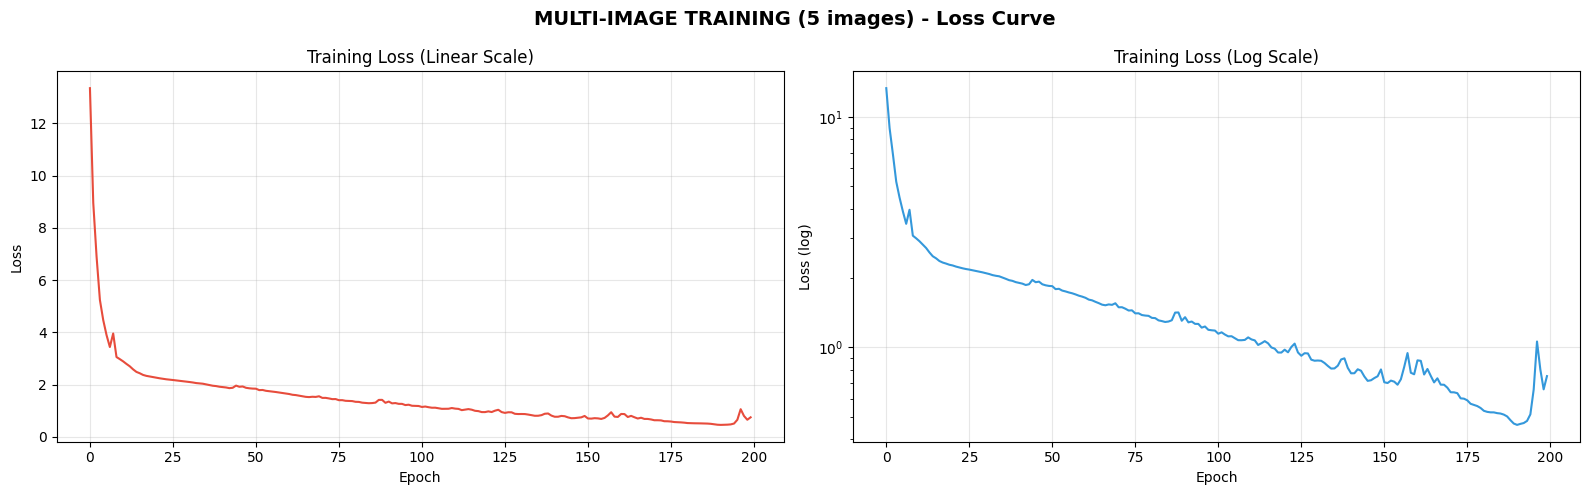

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(losses, color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Linear Scale)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses, color='#3498db', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Training Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'MULTI-IMAGE TRAINING ({len(dataset)} images) - Loss Curve',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:

n_show = min(3, len(dataset))
snap_epochs_sorted = sorted(snapshots.keys())

for img_idx in range(n_show):
    fig, axes = plt.subplots(3, len(snap_epochs_sorted),
                             figsize=(3.5 * len(snap_epochs_sorted), 10))

    for col, ep in enumerate(snap_epochs_sorted):
        snap = snapshots[ep][img_idx]

        axes[0, col].imshow(snap['prob'], cmap='hot', vmin=0, vmax=1)
        axes[0, col].set_title(f'Epoch {ep}', fontsize=10)

        axes[1, col].imshow(snap['thresh'], cmap='hot', vmin=0, vmax=1)

        axes[2, col].imshow(snap['binary'], cmap='gray', vmin=0, vmax=1)

    axes[0, 0].set_ylabel('Probability Map', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Threshold Map', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Binary Map', fontsize=12, fontweight='bold')

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(f'EVOLUTION: Image [{img_idx}] — {dataset_entries[img_idx]["image_filename"][:40]}...',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

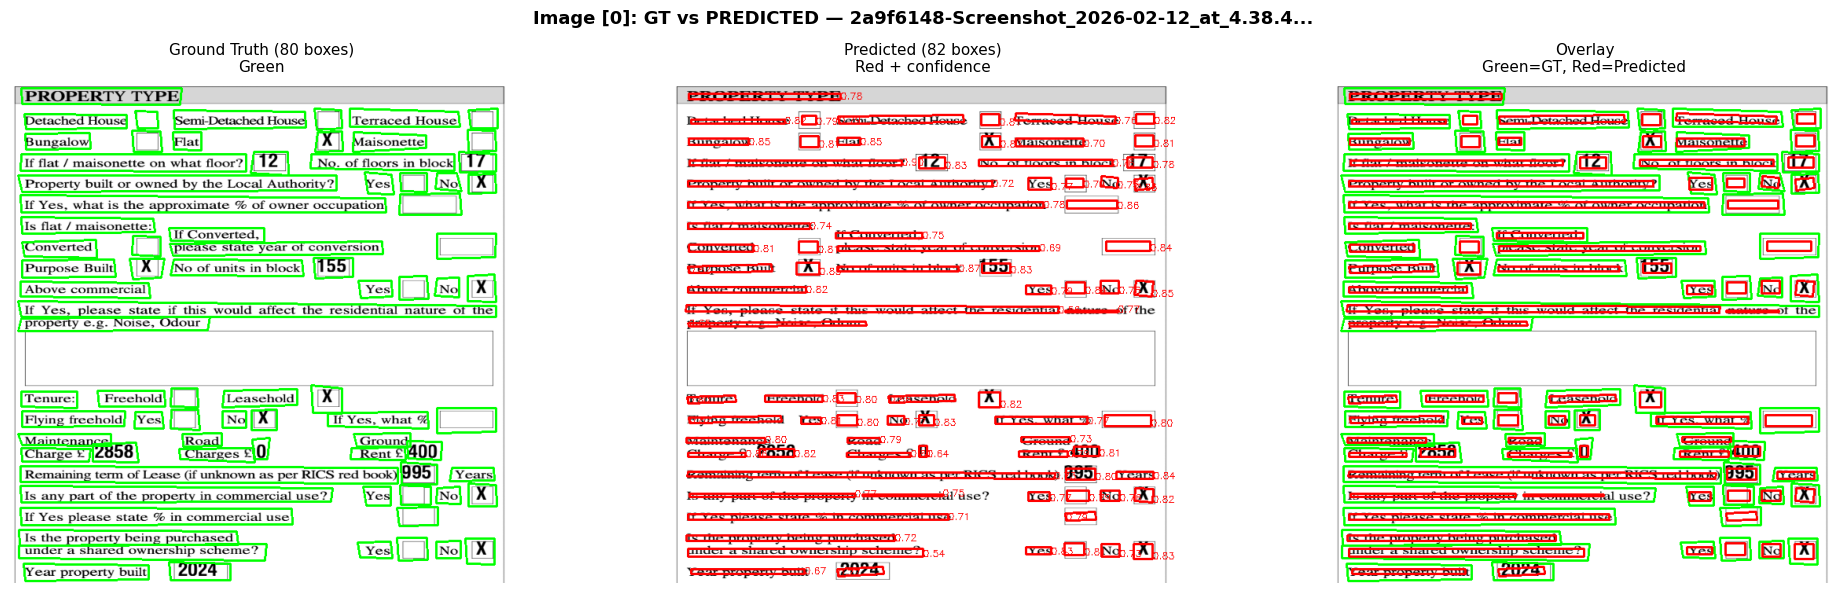

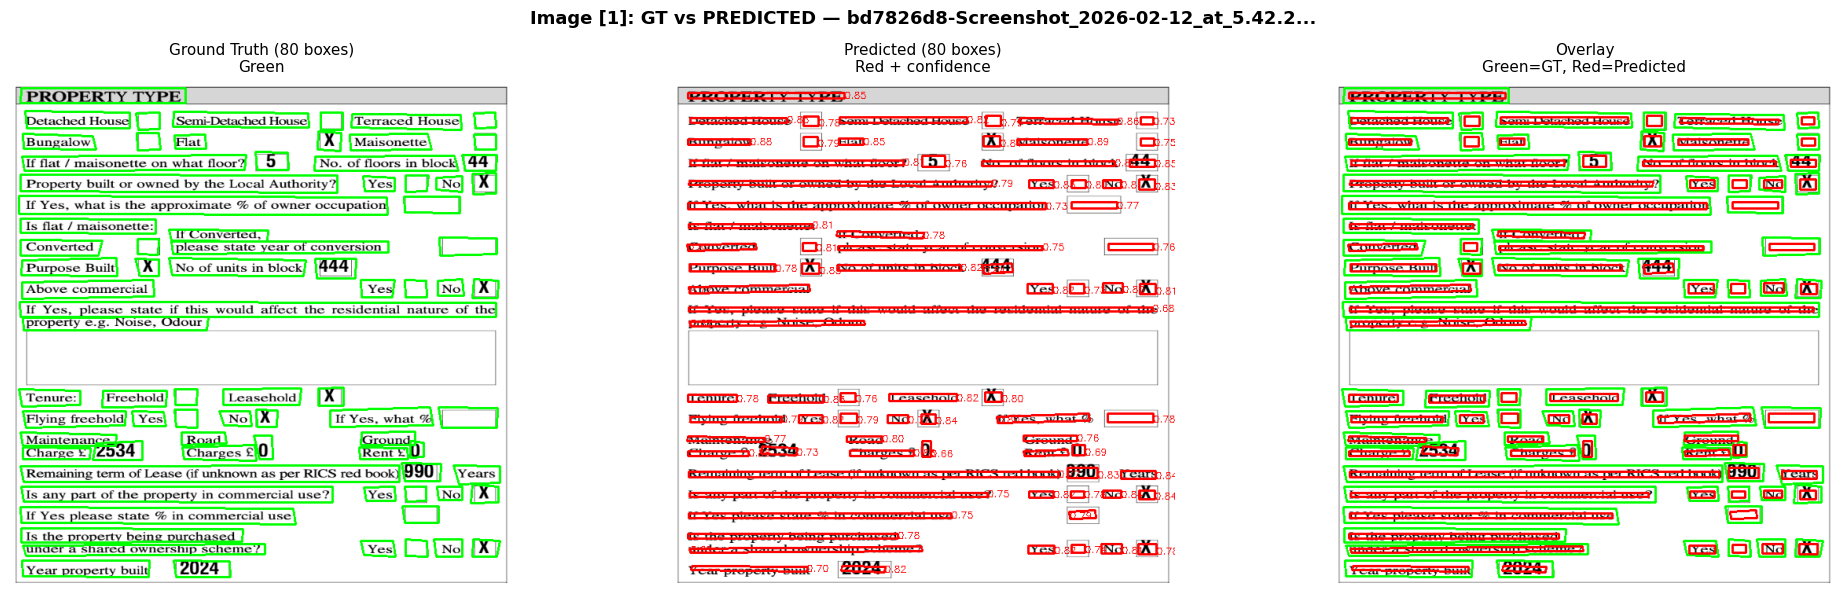

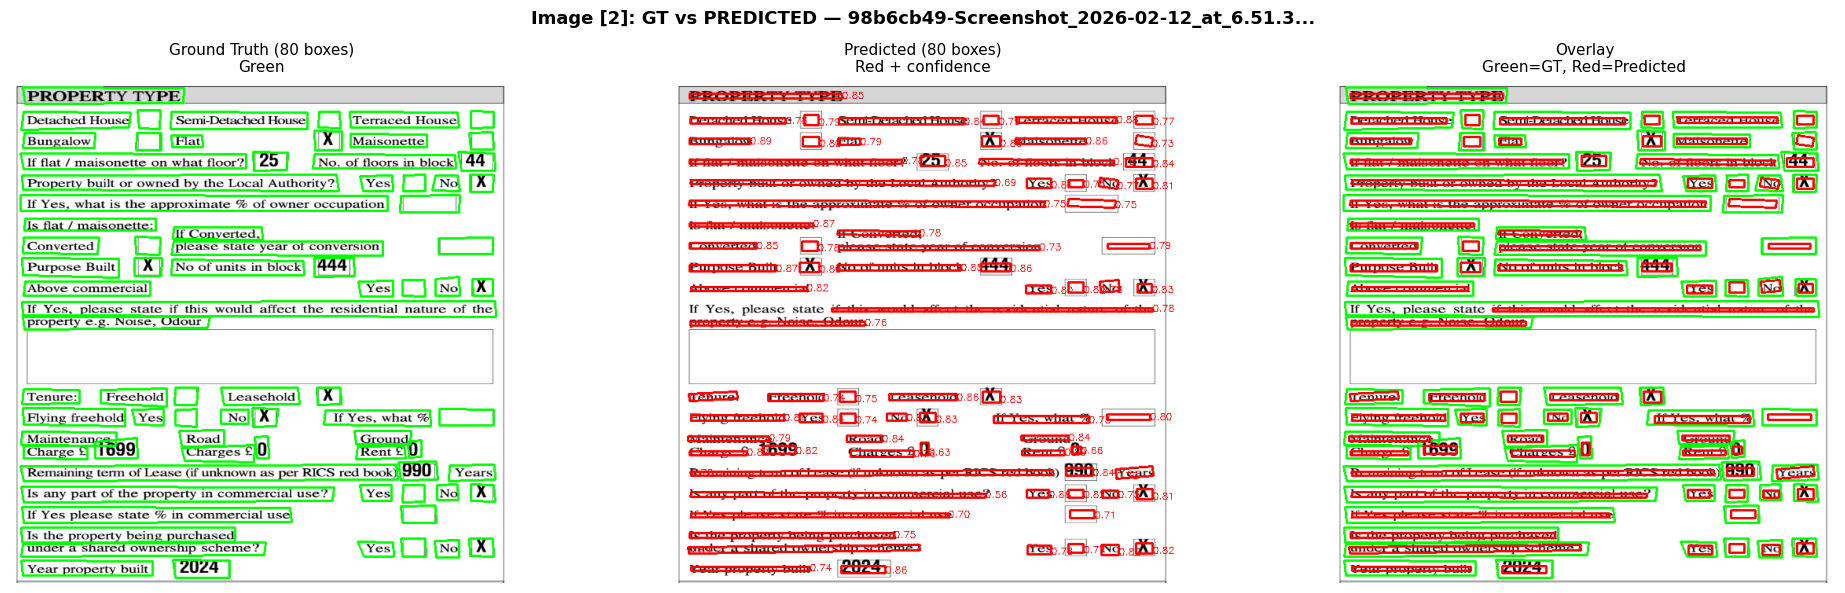

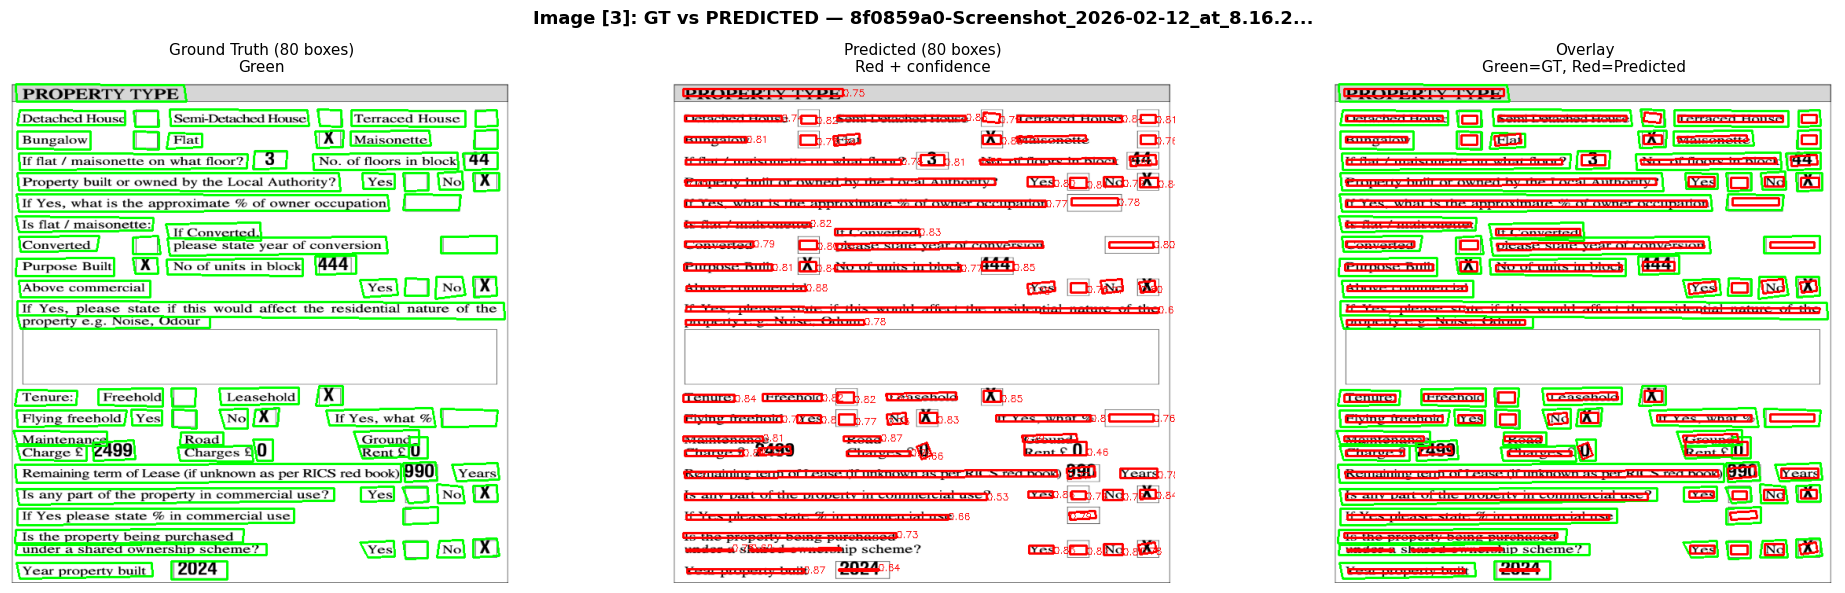

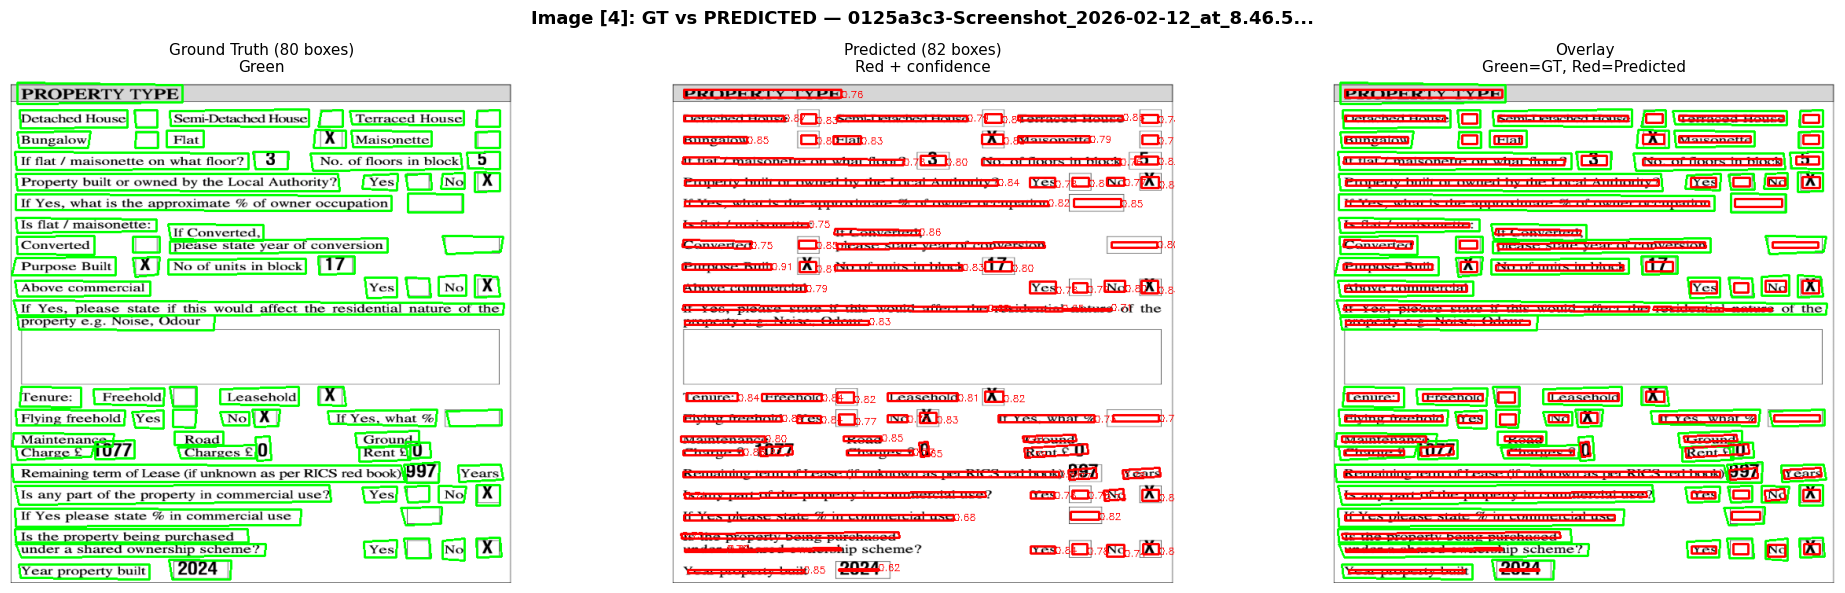

In [13]:

def extract_boxes(binary_map, prob_map, threshold=0.5, min_area=50):
    """Convert binary map to bounding boxes."""
    binary = (binary_map > threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    scores = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect).astype(np.int32)

        mask = np.zeros(binary_map.shape, dtype=np.uint8)
        cv2.fillPoly(mask, [box], 1)
        score = (prob_map * mask).sum() / (mask.sum() + 1e-6)

        if score > 0.3:
            boxes.append(box)
            scores.append(float(score))

    return boxes, scores


# Get final predictions
final_epoch = max(snapshots.keys())

for img_idx in range(len(dataset)):
    entry = dataset_entries[img_idx]
    final = snapshots[final_epoch][img_idx]

    # Get resized image
    img = cv2.imread(str(entry['image_path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    H, W = img.shape[:2]
    scale_x = IMG_SIZE / W
    scale_y = IMG_SIZE / H

    # GT boxes (scaled to 640)
    gt_boxes = []
    for poly in entry['polygons']:
        sp = poly.copy()
        sp[:, 0] *= scale_x
        sp[:, 1] *= scale_y
        gt_boxes.append(sp.astype(np.int32))

    # Predicted boxes
    pred_boxes, pred_scores = extract_boxes(final['binary'], final['prob'])

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # GT
    img_gt = img_resized.copy()
    for box in gt_boxes:
        cv2.polylines(img_gt, [box], True, (0, 255, 0), 2)
    axes[0].imshow(img_gt)
    axes[0].set_title(f'Ground Truth ({len(gt_boxes)} boxes)\nGreen', fontsize=11)
    axes[0].axis('off')

    # Predicted
    img_pred = img_resized.copy()
    for box, score in zip(pred_boxes, pred_scores):
        cv2.polylines(img_pred, [box], True, (255, 0, 0), 2)
        cv2.putText(img_pred, f'{score:.2f}', tuple(box[0]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    axes[1].imshow(img_pred)
    axes[1].set_title(f'Predicted ({len(pred_boxes)} boxes)\nRed + confidence', fontsize=11)
    axes[1].axis('off')

    # Overlay
    img_both = img_resized.copy()
    for box in gt_boxes:
        cv2.polylines(img_both, [box], True, (0, 255, 0), 2)
    for box in pred_boxes:
        cv2.polylines(img_both, [box], True, (255, 0, 0), 2)
    axes[2].imshow(img_both)
    axes[2].set_title(f'Overlay\nGreen=GT, Red=Predicted', fontsize=11)
    axes[2].axis('off')

    plt.suptitle(f'Image [{img_idx}]: GT vs PREDICTED — {entry["image_filename"][:40]}...',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

PIXEL-LEVEL IoU — PER IMAGE + AVERAGE

  Image [0] 2a9f6148-Screenshot_2026-02-12_at_4.38.4...
    TP=45,889  FP= 5,461  FN= 5,952  TN=352,298
    Pixel IoU:  0.8008 (80.08%)
    Precision:  0.8937  Recall: 0.8852  F1: 0.8894

  Image [1] bd7826d8-Screenshot_2026-02-12_at_5.42.2...
    TP=42,132  FP= 6,108  FN= 4,344  TN=357,016
    Pixel IoU:  0.8012 (80.12%)
    Precision:  0.8734  Recall: 0.9065  F1: 0.8896

  Image [2] 98b6cb49-Screenshot_2026-02-12_at_6.51.3...
    TP=39,901  FP= 5,756  FN= 5,482  TN=358,461
    Pixel IoU:  0.7802 (78.02%)
    Precision:  0.8739  Recall: 0.8792  F1: 0.8766

  Image [3] 8f0859a0-Screenshot_2026-02-12_at_8.16.2...
    TP=45,208  FP= 6,105  FN= 6,270  TN=352,017
    Pixel IoU:  0.7851 (78.51%)
    Precision:  0.8810  Recall: 0.8782  F1: 0.8796

  Image [4] 0125a3c3-Screenshot_2026-02-12_at_8.46.5...
    TP=44,859  FP= 6,912  FN= 6,144  TN=351,685
    Pixel IoU:  0.7746 (77.46%)
    Precision:  0.8665  Recall: 0.8795  F1: 0.8730

  AVERAGE ACROSS 5 IM

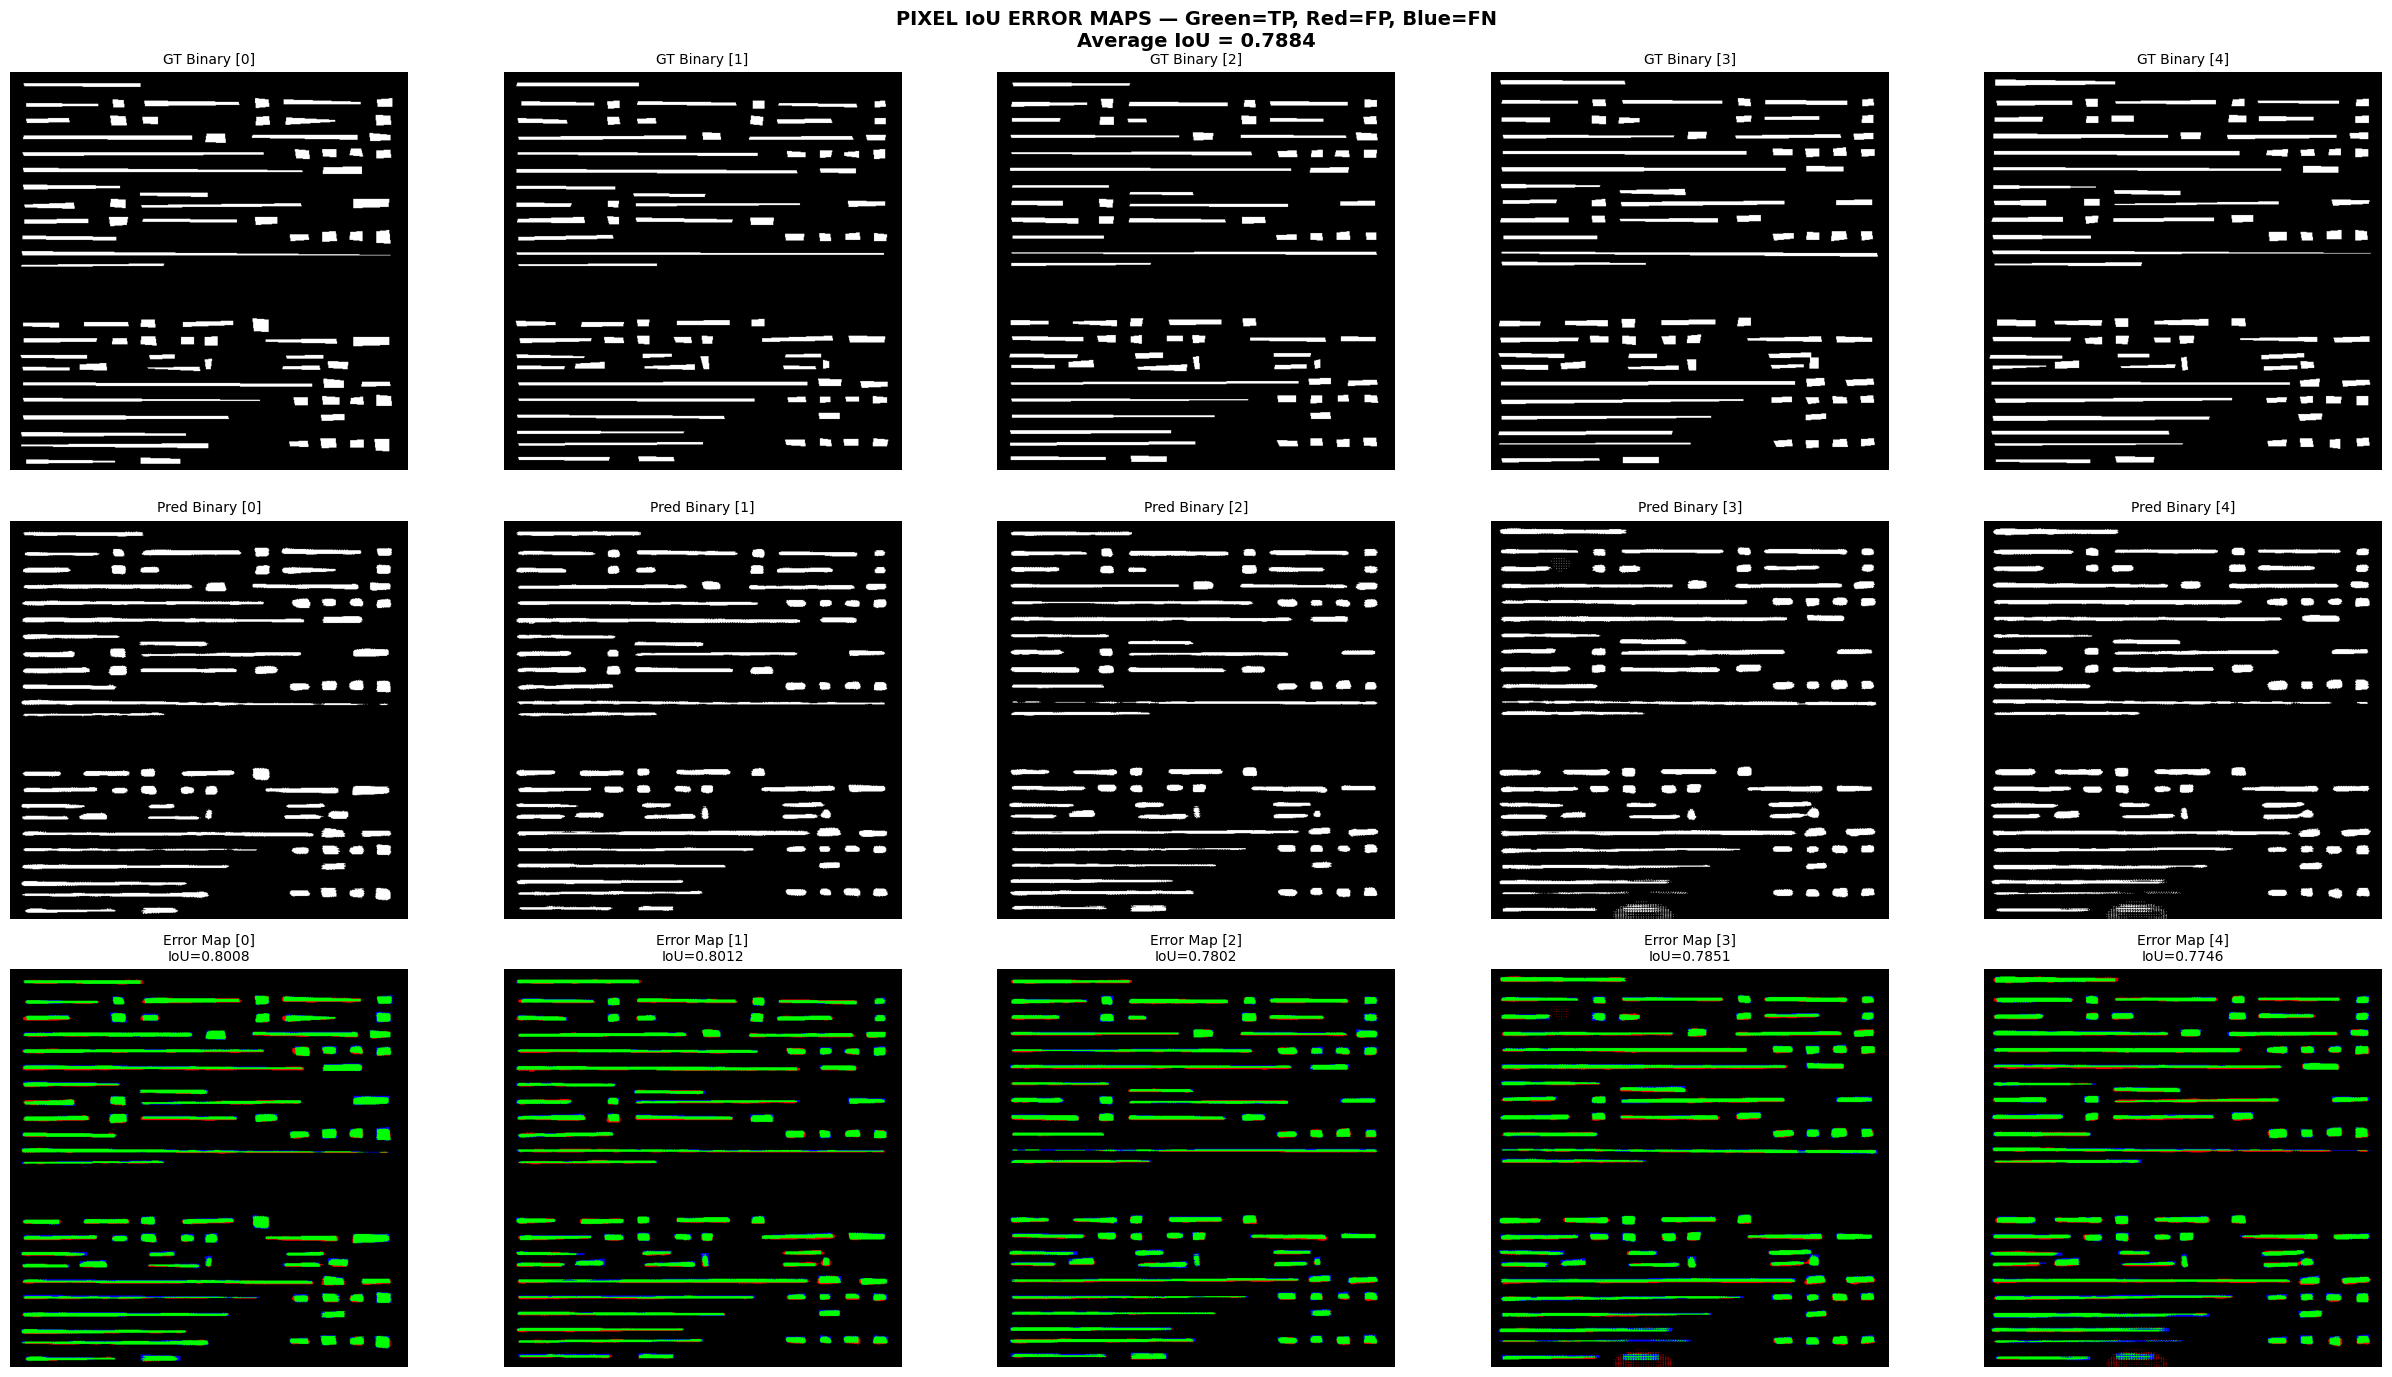

In [14]:

print(f"{'='*60}")
print(f"PIXEL-LEVEL IoU — PER IMAGE + AVERAGE")
print(f"{'='*60}")

all_ious = []
all_precisions = []
all_recalls = []
all_f1s = []

for img_idx in range(len(dataset)):
    entry = dataset_entries[img_idx]
    final = snapshots[final_epoch][img_idx]

    # GT probability map for this image
    _, prob_gt, _, _ = dataset[img_idx]
    gt_binary = (prob_gt[0].numpy() > 0.5).astype(np.uint8)
    pred_binary = (final['binary'] > 0.5).astype(np.uint8)

    assert gt_binary.shape == pred_binary.shape, \
        f"Shape mismatch! GT: {gt_binary.shape}, Pred: {pred_binary.shape}"

    # Pixel counts
    TP = int(((gt_binary == 1) & (pred_binary == 1)).sum())
    FP = int(((gt_binary == 0) & (pred_binary == 1)).sum())
    FN = int(((gt_binary == 1) & (pred_binary == 0)).sum())
    TN = int(((gt_binary == 0) & (pred_binary == 0)).sum())

    intersection = TP
    union = TP + FP + FN

    pixel_iou = intersection / (union + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    all_ious.append(pixel_iou)
    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1s.append(f1)

    print(f"\n  Image [{img_idx}] {entry['image_filename'][:40]}...")
    print(f"    TP={TP:6,}  FP={FP:6,}  FN={FN:6,}  TN={TN:6,}")
    print(f"    Pixel IoU:  {pixel_iou:.4f} ({pixel_iou*100:.2f}%)")
    print(f"    Precision:  {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")

avg_iou = np.mean(all_ious)
avg_precision = np.mean(all_precisions)
avg_recall = np.mean(all_recalls)
avg_f1 = np.mean(all_f1s)

print(f"\n{'='*60}")
print(f"  AVERAGE ACROSS {len(dataset)} IMAGES:")
print(f"    Pixel IoU:  {avg_iou:.4f} ({avg_iou*100:.2f}%)")
print(f"    Precision:  {avg_precision:.4f}")
print(f"    Recall:     {avg_recall:.4f}")
print(f"    F1 Score:   {avg_f1:.4f}")
print(f"{'='*60}")

# Visualize error maps for all images
n_vis = min(len(dataset), 5)
fig, axes = plt.subplots(3, n_vis, figsize=(5 * n_vis, 14))
if n_vis == 1:
    axes = axes[:, np.newaxis]

for i in range(n_vis):
    _, prob_gt, _, _ = dataset[i]
    gt_bin = (prob_gt[0].numpy() > 0.5).astype(np.uint8)
    pred_bin = (snapshots[final_epoch][i]['binary'] > 0.5).astype(np.uint8)

    # Error map
    error_map = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    error_map[(gt_bin == 1) & (pred_bin == 1)] = [0, 255, 0]    # TP → Green
    error_map[(gt_bin == 0) & (pred_bin == 1)] = [255, 0, 0]    # FP → Red
    error_map[(gt_bin == 1) & (pred_bin == 0)] = [0, 0, 255]    # FN → Blue

    axes[0, i].imshow(gt_bin, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'GT Binary [{i}]', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(pred_bin, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Pred Binary [{i}]', fontsize=10)
    axes[1, i].axis('off')

    axes[2, i].imshow(error_map)
    axes[2, i].set_title(f'Error Map [{i}]\nIoU={all_ious[i]:.4f}', fontsize=10)
    axes[2, i].axis('off')

plt.suptitle(f'PIXEL IoU ERROR MAPS — Green=TP, Red=FP, Blue=FN\n'
             f'Average IoU = {avg_iou:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


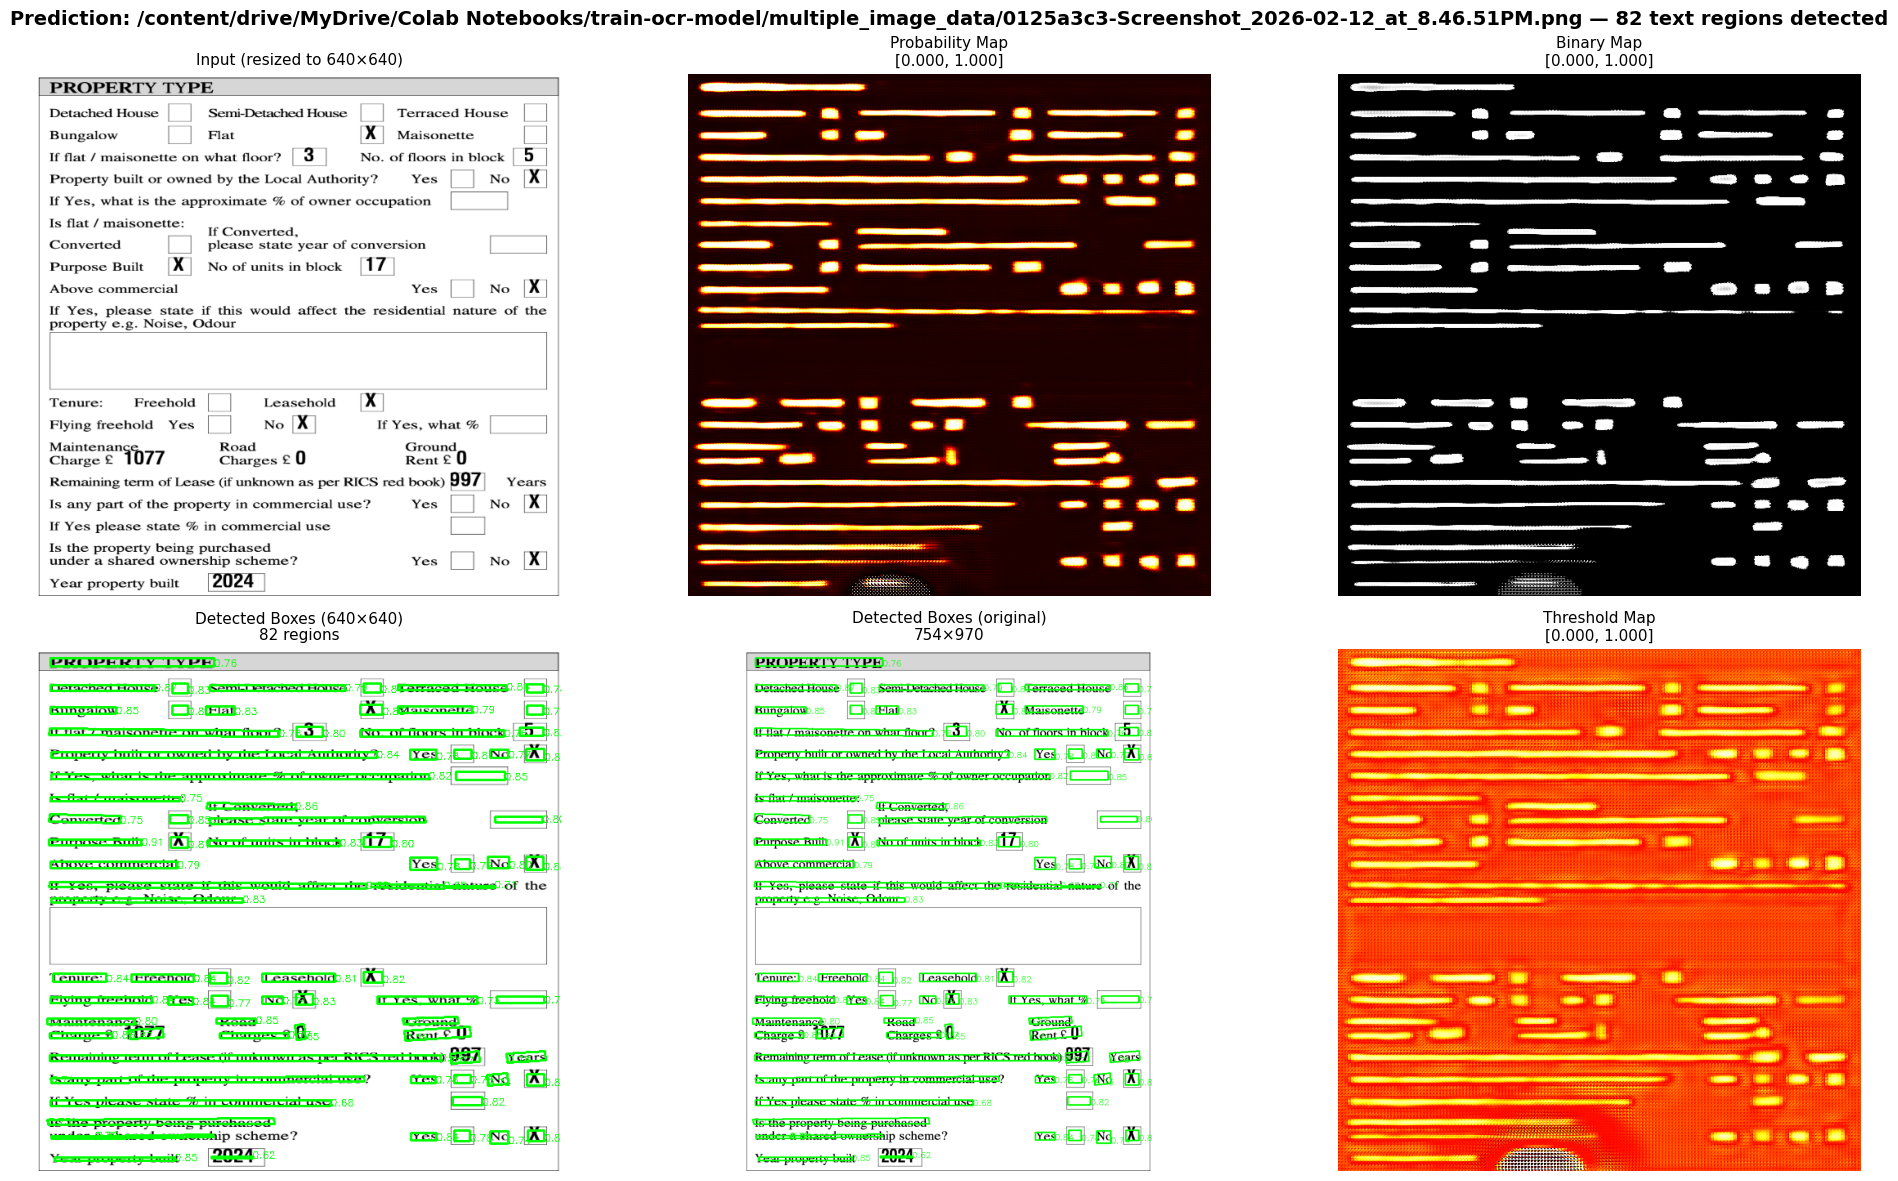

✓ Cell 14 ready! Uncomment an option above to test on a new image.

TRAINING SUMMARY
  Images trained on:  5
  Total text regions: 400
  Final loss:         0.751226
  Average Pixel IoU:  0.7884 (78.84%)
  Average F1 Score:   0.8816 (88.16%)


In [15]:

def predict_on_image(model, image, device, img_size=640, threshold=0.5, min_area=50):
    """Run trained DBNet on any image and return predictions."""
    H, W = image.shape[:2]

    img_resized = cv2.resize(image, (img_size, img_size))
    img_input = img_resized.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_input).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob, thresh, binary = model(img_tensor)

    prob_np = prob[0, 0].cpu().numpy()
    thresh_np = thresh[0, 0].cpu().numpy()
    binary_np = binary[0, 0].cpu().numpy()

    boxes, scores = extract_boxes(binary_np, prob_np, threshold, min_area)

    # Scale boxes back to original size
    scale_x = W / img_size
    scale_y = H / img_size
    original_boxes = []
    for box in boxes:
        scaled = box.astype(np.float32)
        scaled[:, 0] *= scale_x
        scaled[:, 1] *= scale_y
        original_boxes.append(scaled.astype(np.int32))

    return {
        'prob_map': prob_np,
        'thresh_map': thresh_np,
        'binary_map': binary_np,
        'boxes': original_boxes,
        'boxes_640': boxes,
        'scores': scores,
        'resized_image': img_resized,
    }


def visualize_prediction(image, result, title="Prediction"):
    """Visualize prediction outputs."""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    axes[0, 0].imshow(result['resized_image'])
    axes[0, 0].set_title(f'Input (resized to {IMG_SIZE}×{IMG_SIZE})', fontsize=11)

    axes[0, 1].imshow(result['prob_map'], cmap='hot', vmin=0, vmax=1)
    axes[0, 1].set_title(f"Probability Map\n[{result['prob_map'].min():.3f}, {result['prob_map'].max():.3f}]", fontsize=11)

    axes[0, 2].imshow(result['binary_map'], cmap='gray', vmin=0, vmax=1)
    axes[0, 2].set_title(f"Binary Map\n[{result['binary_map'].min():.3f}, {result['binary_map'].max():.3f}]", fontsize=11)

    img_640 = result['resized_image'].copy()
    for box, score in zip(result['boxes_640'], result['scores']):
        cv2.polylines(img_640, [box], True, (0, 255, 0), 2)
        cv2.putText(img_640, f'{score:.2f}', tuple(box[0]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
    axes[1, 0].imshow(img_640)
    axes[1, 0].set_title(f'Detected Boxes (640×640)\n{len(result["boxes"])} regions', fontsize=11)

    img_orig = image.copy()
    for box, score in zip(result['boxes'], result['scores']):
        cv2.polylines(img_orig, [box], True, (0, 255, 0), 2)
        cv2.putText(img_orig, f'{score:.2f}', tuple(box[0]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    axes[1, 1].imshow(img_orig)
    axes[1, 1].set_title(f'Detected Boxes (original)\n{image.shape[1]}×{image.shape[0]}', fontsize=11)

    axes[1, 2].imshow(result['thresh_map'], cmap='hot', vmin=0, vmax=1)
    axes[1, 2].set_title(f"Threshold Map\n[{result['thresh_map'].min():.3f}, {result['thresh_map'].max():.3f}]", fontsize=11)

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(f'{title} — {len(result["boxes"])} text regions detected',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ————————————————————————————————————————————————————
# OPTION 1: Test with an image from file path
# ————————————————————————————————————————————————————

# /content/drive/MyDrive/Colab Notebooks/train-ocr-model/multiple_image_data/0125a3c3-Screenshot_2026-02-12_at_8.46.51PM.png

test_image_path = '/content/drive/MyDrive/Colab Notebooks/train-ocr-model/multiple_image_data/0125a3c3-Screenshot_2026-02-12_at_8.46.51PM.png'
test_img = cv2.imread(test_image_path)
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
result = predict_on_image(model, test_img, device)
visualize_prediction(test_img, result, title=f"Prediction: {test_image_path}")

# ————————————————————————————————————————————————————
# OPTION 2: Test with uploaded image (Colab)
# ————————————————————————————————————————————————————
# from google.colab import files
# uploaded = files.upload()
# for fname in uploaded:
#     nparr = np.frombuffer(uploaded[fname], np.uint8)
#     test_img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
#     test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
#     result = predict_on_image(model, test_img, device)
#     visualize_prediction(test_img, result, title=f"Prediction: {fname}")

print("✓ Cell 14 ready! Uncomment an option above to test on a new image.")
print(f"\n{'='*60}")
print(f"TRAINING SUMMARY")
print(f"{'='*60}")
print(f"  Images trained on:  {len(dataset)}")
print(f"  Total text regions: {total_regions}")
print(f"  Final loss:         {losses[-1]:.6f}")
print(f"  Average Pixel IoU:  {avg_iou:.4f} ({avg_iou*100:.2f}%)")
print(f"  Average F1 Score:   {avg_f1:.4f} ({avg_f1*100:.2f}%)")
print(f"{'='*60}")
